## Reading hdf5 files and conversion to cgs or MKS systems

In [1]:
import numpy as np
import h5py
import os

In [2]:
def read_maps(path):
    """
    Reads vr, rho, p HDF5 file and returns the data and coordinates.
    """
    with h5py.File(path, "r") as f:
        vr = f["vr"][:]
        rho = f["rho"][:]
        p = f["p"][:]
        phi = f["phi"][:]
        theta = f["theta"][:]
        r = f["r"][:]

    return vr, rho, p, phi, theta, r

In [3]:
def code_units_to_cgs(vr, rho, p, r):
    physical_vr = vr * 481.3711 * 1e5    # cm / s
    physical_rho = rho * 1.6726 * 1e-16  # g / cm^3
    physical_p = p * 0.3875717           # dyn / cm^2
    physical_r = r * 6.96 * 1e10         # cm
    return physical_vr, physical_rho, physical_p, physical_r

In [4]:
def code_units_to_mks(vr, rho, p, r):
    physical_vr = vr * 481.3711 * 1e3     # m / s
    physical_rho = rho * 1.6726 * 1e-13   # kg / m^3
    physical_p = p * 0.03875717           # Pascals (N / m^2)
    physical_r = r * 6.96 * 1e8           # m
    return physical_vr, physical_rho, physical_p, physical_r

In [5]:
maps_path = "/Users/reza/Career/DMLab/SURROGATE/Data/all-components/boundary-conditions/cr2239/hmi_mast_mas_std_0201/vr_rho_p_r0.h5"
vr, rho, p, phi, theta, r = read_maps(maps_path)
vr_cgs, rho_cgs, p_cgs, r_cgs = code_units_to_cgs(vr, rho, p, r)
vr_mks, rho_mks, p_mks, r_mks = code_units_to_mks(vr, rho, p, r)

In [6]:
print(
    "vr shape",
    vr.shape, "-> representing (phi, theta)"
    "\nrho shape",
    rho.shape,
    "\np shape",
    p.shape,
    "\nphi shape",
    phi.shape,
    "\ntheta shape",
    theta.shape,
    "\nr shape",
    r.shape,
)

vr shape (128, 109) -> representing (phi, theta)
rho shape (128, 109) 
p shape (128, 109) 
phi shape (128,) 
theta shape (109,) 
r shape (1,)


## Examining values

In [7]:
import matplotlib.pyplot as plt

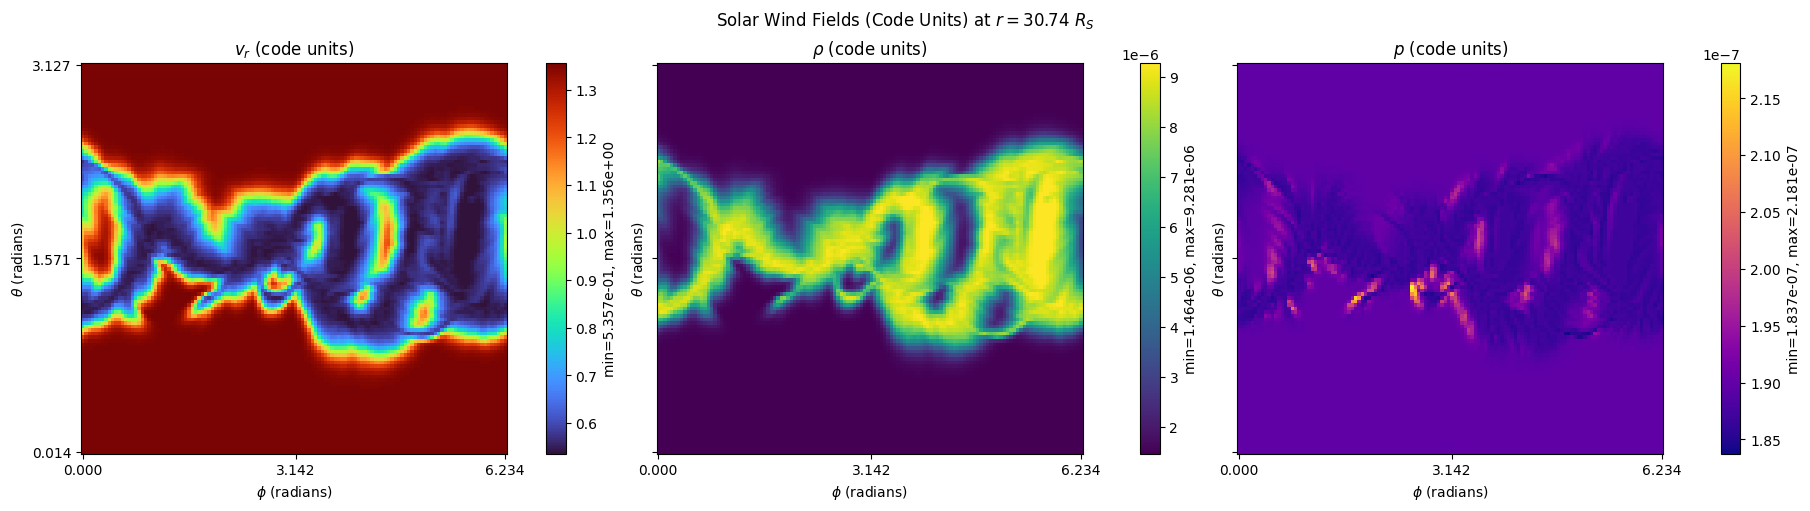

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True, sharey=True)

fields = [vr, rho, p]

titles = ["$v_r$ (code units)", r"$\rho$ (code units)", "$p$ (code units)"]
cmaps  = ["turbo", "viridis", "plasma"]

for i, (ax, field, title, cmap) in enumerate(zip(axes, fields, titles, cmaps)):
    
    data = field
    
    im = ax.pcolormesh(
        phi,
        theta,
        data.T,
        shading="auto",
        cmap=cmap
    )

    ax.set_yticks([theta[0], theta[len(theta)//2], theta[-1]])
    ax.set_xticks([phi[0], phi[len(phi)//2], phi[-1]])
    
    vmin = np.nanmin(data)
    vmax = np.nanmax(data)
    
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"min={vmin:.3e}, max={vmax:.3e}")
    
    ax.set_title(title)
    ax.set_xlabel(r"$\phi$ (radians)")
    ax.set_ylabel(r"$\theta$ (radians)")

plt.suptitle(f"Solar Wind Fields (Code Units) at $r = {r[0]:.2f}\ R_S$")
plt.show()

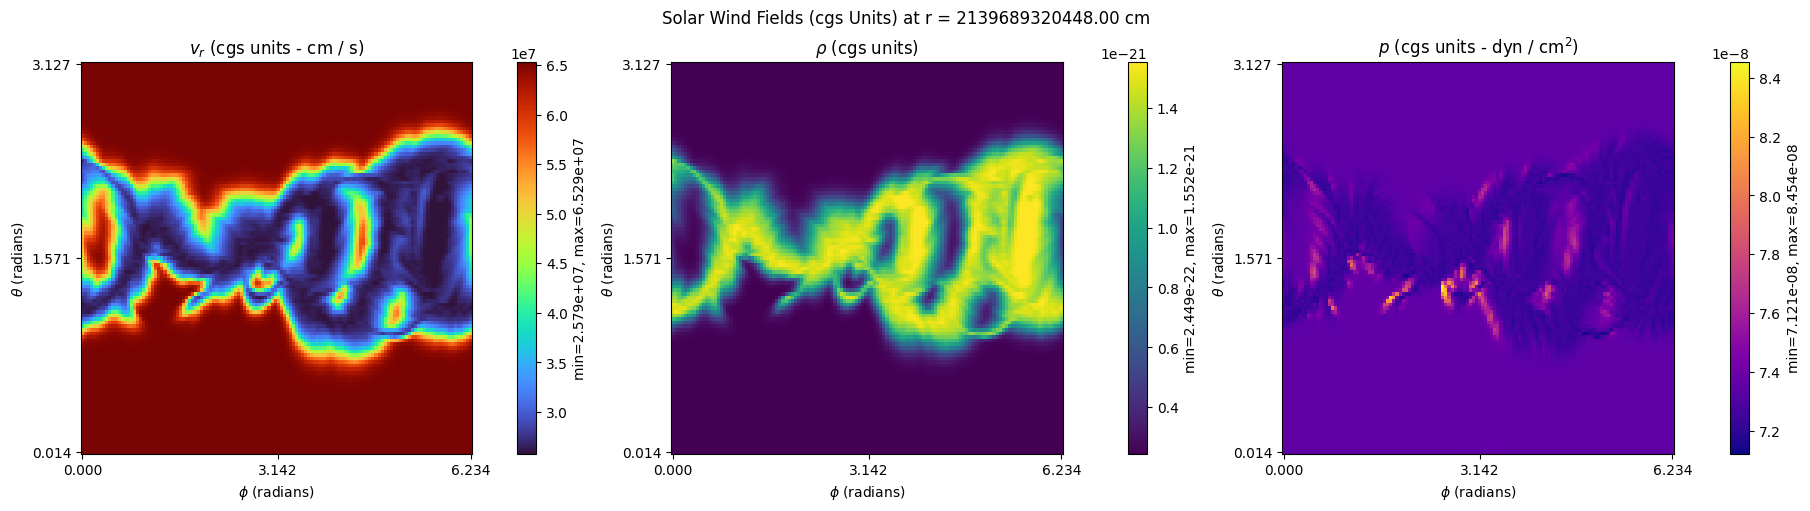

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

fields = [vr_cgs, rho_cgs, p_cgs]

titles = ["$v_r$ (cgs units - cm / s)", r"$\rho$ (cgs units)", "$p$ (cgs units - dyn / cm$^2$)"]
cmaps  = ["turbo", "viridis", "plasma"]

for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
    
    data = field
    
    im = ax.pcolormesh(
        phi,
        theta,
        data.T,
        shading="auto",
        cmap=cmap
    )
    
    ax.set_yticks([theta[0], theta[len(theta)//2], theta[-1]])
    ax.set_xticks([phi[0], phi[len(phi)//2], phi[-1]])
    
    vmin = np.nanmin(data)
    vmax = np.nanmax(data)
    
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"min={vmin:.3e}, max={vmax:.3e}")
    
    ax.set_title(title)
    ax.set_xlabel(r"$\phi$ (radians)")
    ax.set_ylabel(r"$\theta$ (radians)")


plt.suptitle(f"Solar Wind Fields (cgs Units) at r = {r_cgs[0]:.2f} cm")
plt.show()

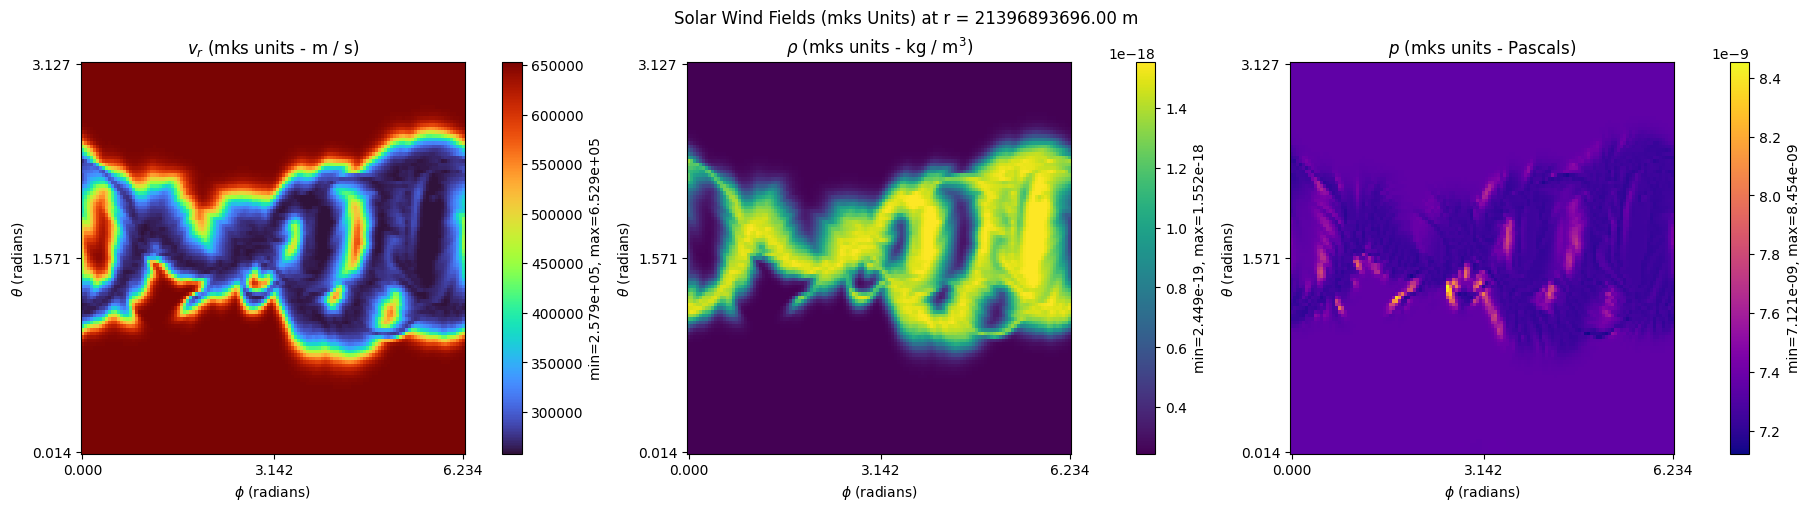

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

fields = [vr_mks, rho_mks, p_mks]

titles = ["$v_r$ (mks units - m / s)", r"$\rho$ (mks units - kg / m$^3$)", "$p$ (mks units - Pascals)"]
cmaps  = ["turbo", "viridis", "plasma"]

for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
    
    data = field
    
    im = ax.pcolormesh(
        phi,
        theta,
        data.T,
        shading="auto",
        cmap=cmap
    )
    
    ax.set_yticks([theta[0], theta[len(theta)//2], theta[-1]])
    ax.set_xticks([phi[0], phi[len(phi)//2], phi[-1]])
    
    vmin = np.nanmin(data)
    vmax = np.nanmax(data)
    
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"min={vmin:.3e}, max={vmax:.3e}")
    
    ax.set_title(title)
    ax.set_xlabel(r"$\phi$ (radians)")
    ax.set_ylabel(r"$\theta$ (radians)")

plt.suptitle(f"Solar Wind Fields (mks Units) at r = {r_mks[0]:.2f} m")
plt.show()